# Real hardware backend data

Inspect trusted local backend snapshots, compare calibrations, and reconstruct circuit placement offline. Plotting and analysis code lives in `qgan/src/qgan_v2/analysis`; this notebook provides settings and calls. No IBM account or session is required.

### Setup

Run with the Qiskit environment used by the project. Snapshot paths and saved configurations can be changed below.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

repo_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "qgan/src").is_dir())
sys.path.insert(0, str(repo_root / "qgan/src"))
from qgan_v2.analysis import BackendAnalysis

analysis = BackendAnalysis(repo_root)
BACKEND_FILES = {
    "Noisy": "qgan/backends/ibm_basquecountry.pkl",
    "Real SPSA": "qgan/data/train/base-qml_torch-q4-real-SPSA-aerCPU-rand0-seed0/real_backend.pkl",
    "Real PSR": "qgan/data/train/base-qml_torch-q4-real-PSR-aerCPU-rand0-seed0/real_backend.pkl",
}
RUN_CONFIG_FILES = {
    "Noisy": "qgan/data/train/base-qml_torch-q4-noisy-SPSA-aerCPU-rand0-seed0/config.yaml",
    "Real SPSA": "qgan/data/train/base-qml_torch-q4-real-SPSA-aerCPU-rand0-seed0/config.yaml",
    "Real PSR": "qgan/data/train/base-qml_torch-q4-real-PSR-aerCPU-rand0-seed0/config.yaml",
}

## 1. Selected backend

### Physical topology and calibrated chip layouts

Choose a reference or set `SELECTED_BACKEND_FILE` to another trusted local pickle. The diagram describes the snapshot’s physical chip and calibration, rather than historical job placement.

Set the selected-backend PNG toggle to `True` to save the calibrated chip diagram as one 300-dpi PNG, or `False` to display it without saving. `analysis.load_backend(..., save_figures=True, filename="selected_backend_layout")` optionally sets the output stem. Files go to `analysis.figure_dir`; the default name includes the snapshot stem and property-update date.


`load_backend(..., title="My hardware layout")` replaces the diagram title in both the exported PNG and `analysis.show_layout(selected_snapshot)`. Omit `title` to retain the default backend, source path, and property-update date heading. The custom title affects the returned snapshot view; other loads retain their default heading.


Backend layout PNG saved: /home/benat/Qiskit-IBM/qgan/figures/rh_backend_data/ibm_basquecountry_layout.png


**ibm_basquecountry** · 156 physical qubits · 176 physical links · processor Heron revision 2 · native basis gates: cz, id, rz, sx, x.

Saved physical coordinates.

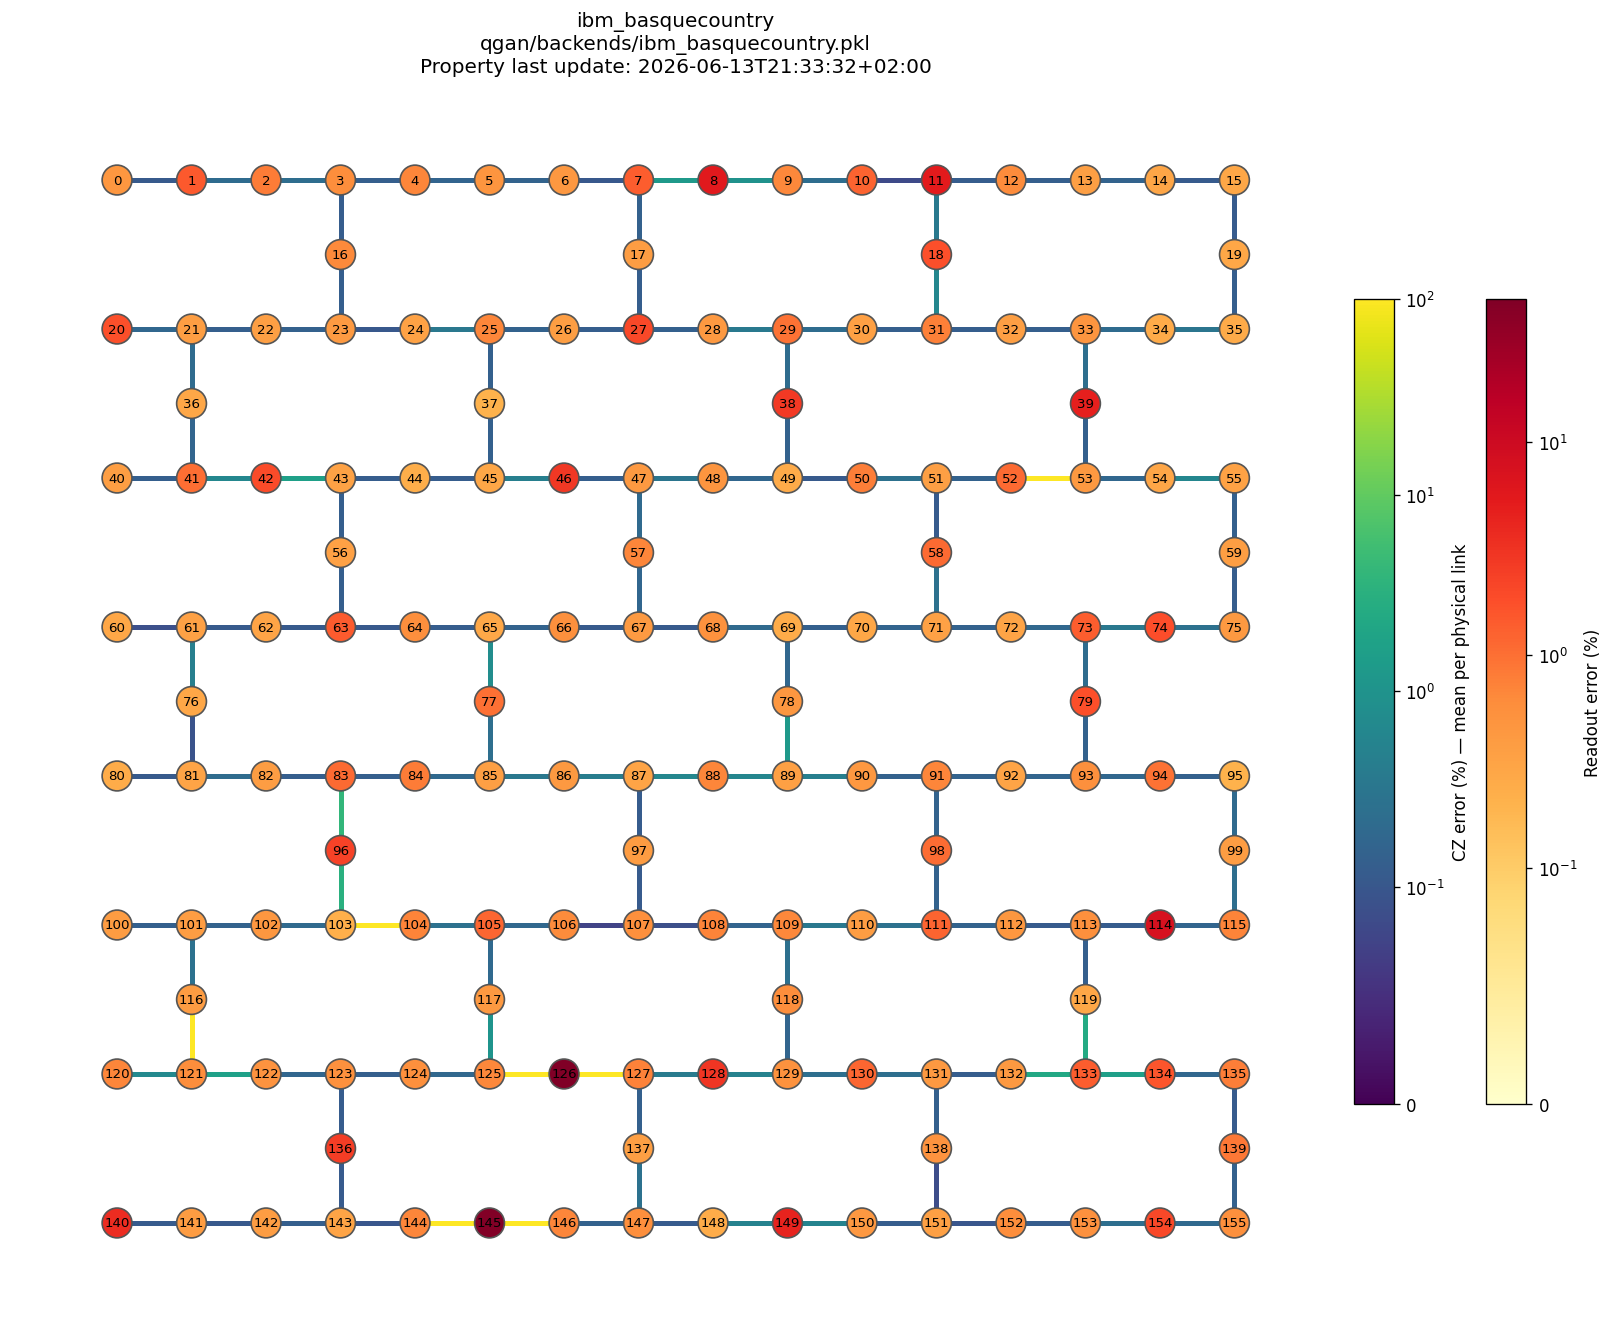

In [5]:
SELECTED_BACKEND = "Noisy"
CREATE_PNG = False

SELECTED_BACKEND_FILE = BACKEND_FILES[SELECTED_BACKEND]
selected_snapshot = analysis.load_backend(
    SELECTED_BACKEND_FILE,
    save_figures=True,
    filename="ibm_basquecountry_layout"
)
analysis.show_layout(selected_snapshot)

### Calibration summaries and gate/instruction tables

The qubit calibration summary and gate calibration summary report available values with explicit units. Missing operational flags do not establish hardware health; snapshot calibrations do not recover job-level state.

In [3]:
qubit_summary, gate_summary = analysis.show_calibration_summary(selected_snapshot)

Metric,N,Min,Q1,Median,Mean,Q3,Max
T1 (us),156,9.45163,205.779,260.452,252.744,301.425,424.841
T2 (us),156,17.0851,92.5615,177.27,190.612,267.487,491.531
Readout error (%),156,0.20752,0.354004,0.506592,1.43198,0.808716,46.8506
Initialization error (%),0,N/A,N/A,N/A,N/A,N/A,N/A
P(1|0) (%),156,0,0.12207,0.244141,1.09253,0.512695,52.7832
P(0|1) (%),156,0.292969,0.537109,0.732422,1.77612,1.32446,48.7549
Readout duration (ns),156,2180,2180,2180,2180,2180,2180
Frequency (GHz),0,N/A,N/A,N/A,N/A,N/A,N/A


Gate,Metric,N,Min,Q1,Median,Mean,Q3,Max
cz,Error (%),352,0.0737878,0.125791,0.155137,4.27633,0.256645,100
cz,Duration (ns),352,68,68,68,68.1818,68,84
id,Error (%),156,0.00727334,0.0176463,0.0238094,1.31943,0.0350878,100
id,Duration (ns),156,32,32,32,32,32,32
measure,Error (%),156,0.20752,0.354004,0.506592,1.43198,0.808716,46.8506
measure,Duration (ns),156,2180,2180,2180,2180,2180,2180
reset,Error (%),0,N/A,N/A,N/A,N/A,N/A,N/A
reset,Duration (ns),156,2212,2212,2212,2212,2212,2212
rx,Error (%),156,0.00727334,0.0176463,0.0238094,1.31943,0.0350878,100
rx,Duration (ns),156,32,32,32,32,32,32


## 2. Calibration comparisons

### Compare errors

Two figures compare qubit and gate errors across the three snapshots. The references have different calibration dates; these descriptive differences do not isolate an optimizer effect.

Both comparison functions accept `filename` as a shared file stem. For example, `filename="backend_errors"` saves `backend_errors_qubit.png` and `backend_errors_gate.png`; `filename="backend_times"` saves the corresponding time figures. Files are created only with `save_figures=True`. Omitting `filename` retains the default names.


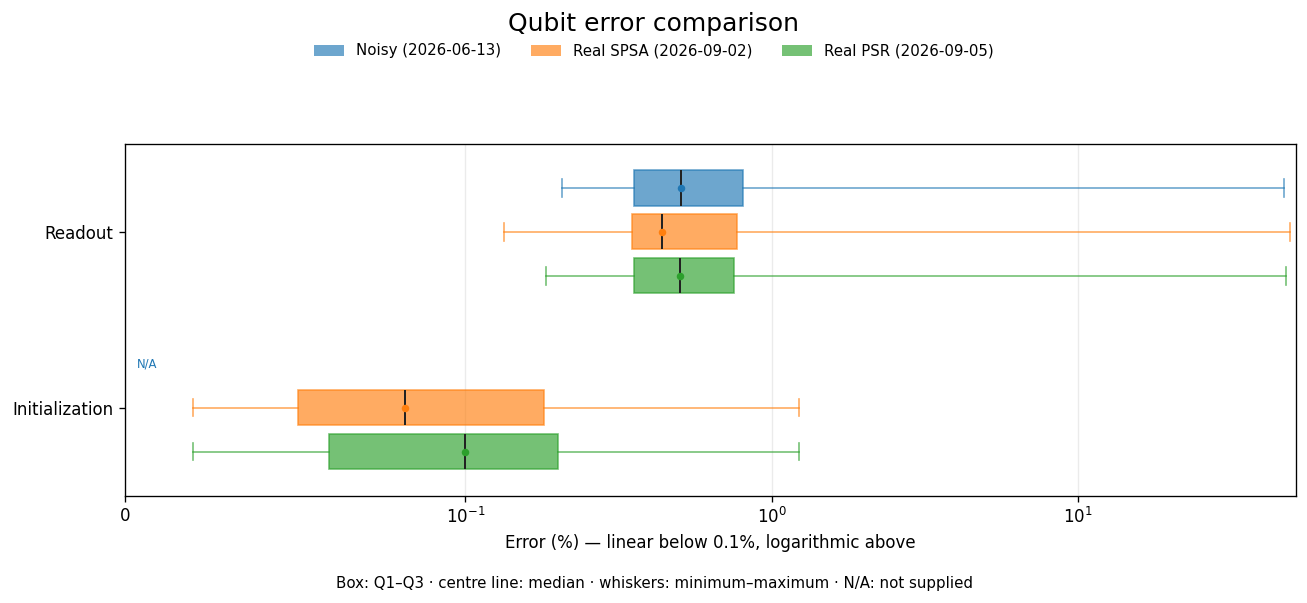

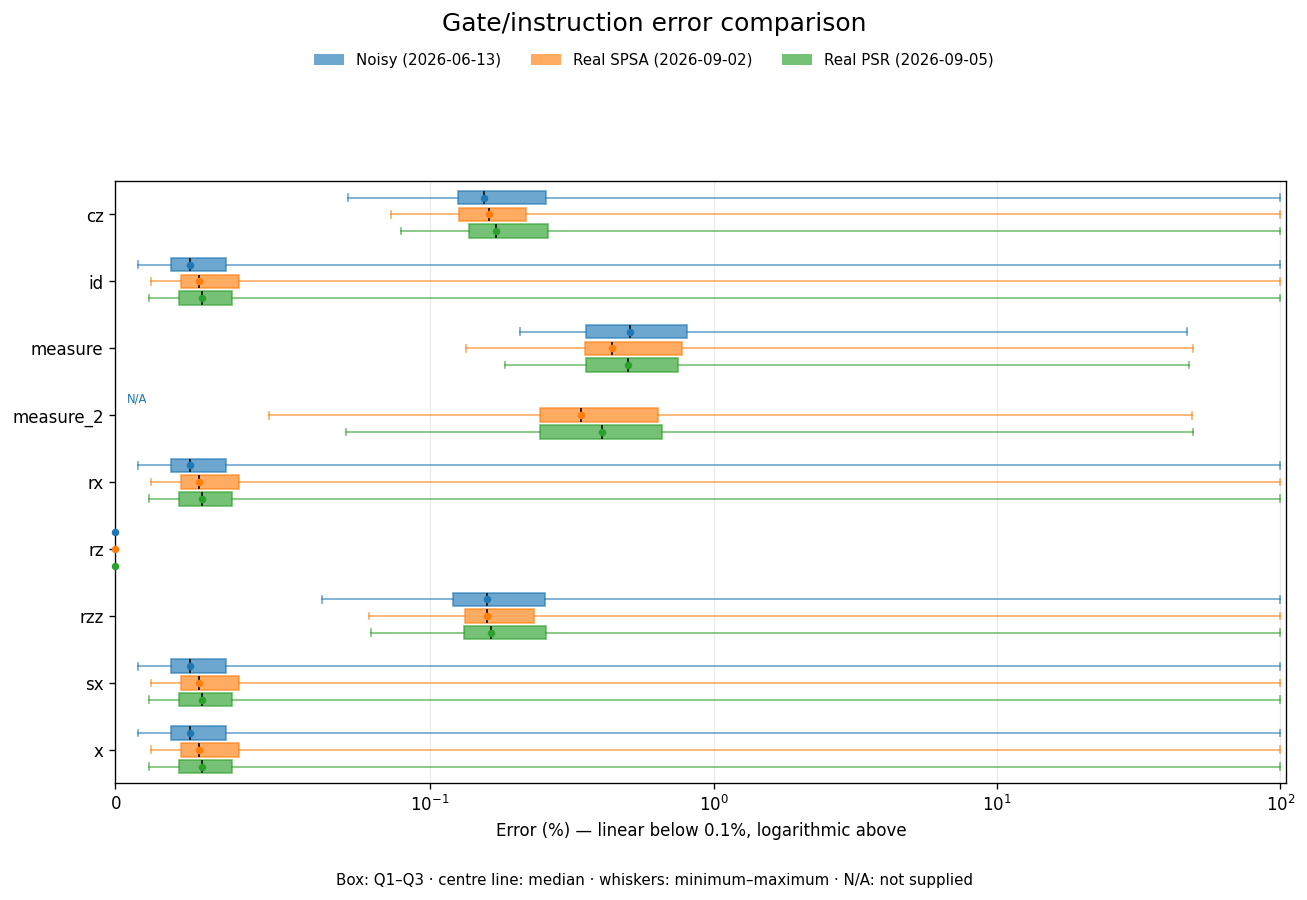

All comparison snapshots passed completeness and unit-conversion checks.
Comparison images saved in: /home/benat/Qiskit-IBM/qgan/figures/rh_backend_data


In [4]:
error_comparison = analysis.compare_errors(BACKEND_FILES, save_figures=CREATE_PNG, filename="backend_errors")

### Compare times

Compare qubit T1/T2/readout times and gate durations. T1 and T2 describe relaxation/coherence, rather than circuit execution duration. These values cannot establish actual session duration.

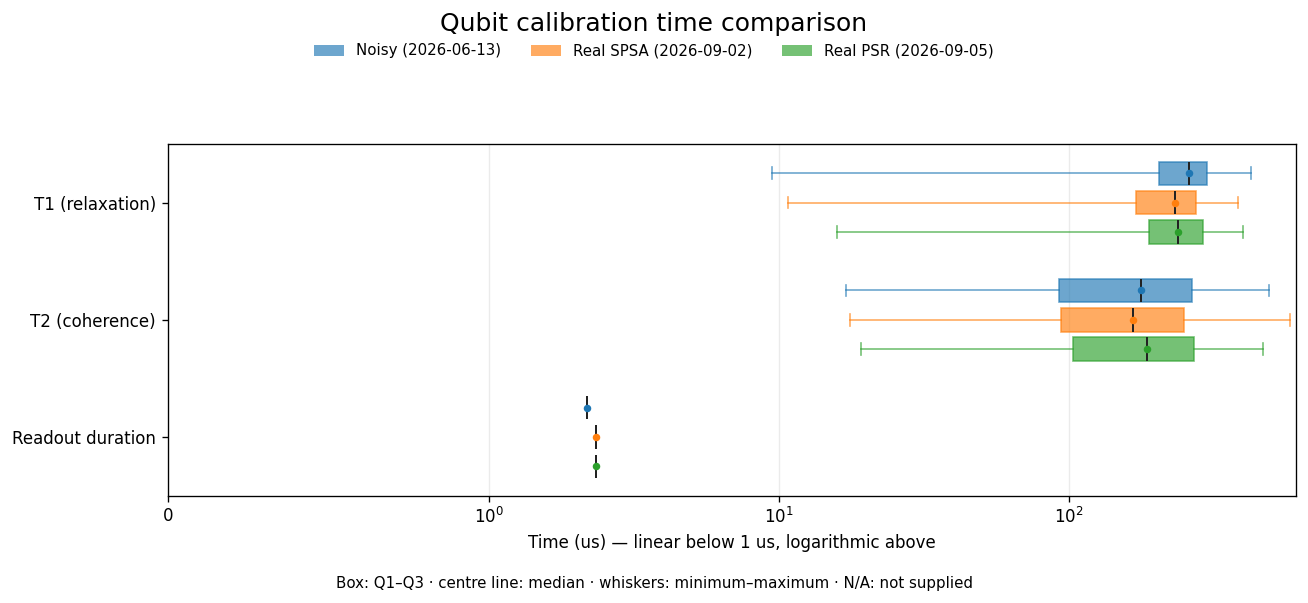

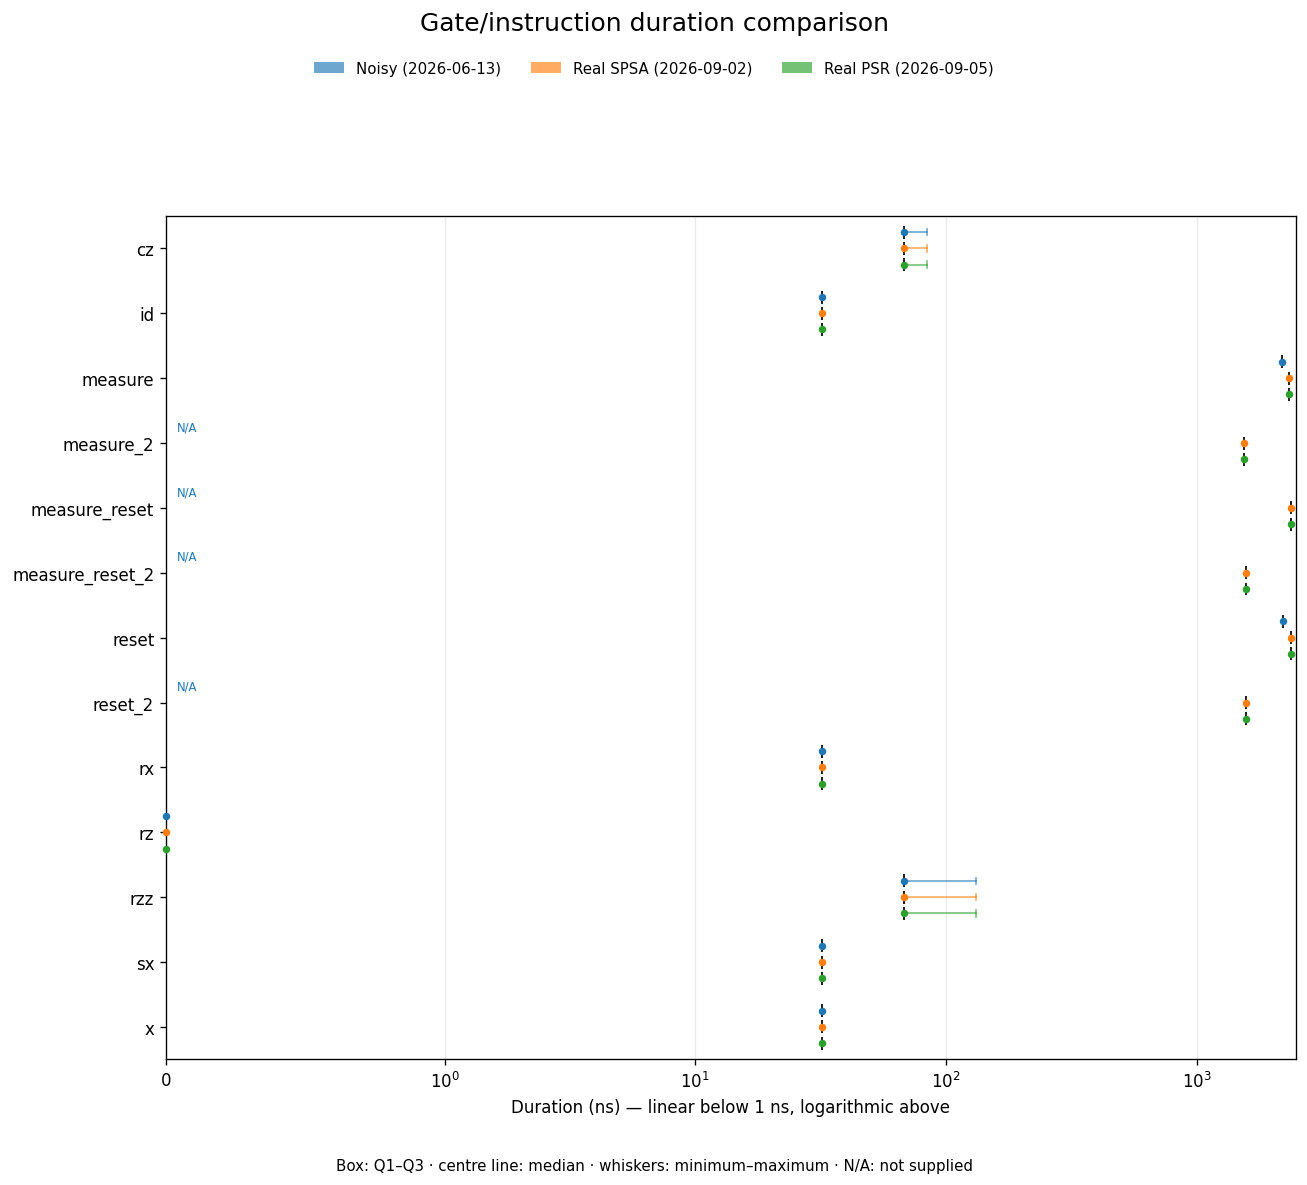

All comparison snapshots passed completeness and unit-conversion checks.
Comparison images saved in: /home/benat/Qiskit-IBM/qgan/figures/rh_backend_data


In [5]:
time_comparison = analysis.compare_times(BACKEND_FILES, save_figures=CREATE_PNG, filename="backend_times")

## 3. Offline circuit transpilation and physical-qubit placement

Choose a matching saved configuration for the local backend target. Reports retain initial/final physical mappings, active qubits, depth, instruction counts, CZ counts, settings, and software versions. These are new compilations of unbound templates, before gradients and Runtime measurement/mitigation expansion; historical job circuits, effective hardware shots, and session durations are not recovered.

`USE_DEFAULT_LAYOUT = True` uses Qiskit’s default layout pipeline for new offline compilations, overriding the saved `layout_method: sabre` without editing historical configs. The saved run circuits are not recovered. Inspect the used CZ links and their calibration errors before interpreting a placement.

In [3]:
PLACEMENT_REFERENCE = 'Real SPSA'
PLACEMENT_BACKEND_FILE = BACKEND_FILES[PLACEMENT_REFERENCE]
PLACEMENT_CONFIG_FILE = RUN_CONFIG_FILES[PLACEMENT_REFERENCE]
USE_DEFAULT_LAYOUT = True
SAVE_RECONSTRUCTED_CIRCUITS = True
TRANSPILE_OUTPUT_DIR = repo_root / 'qgan/data/backend_analysis/default_layout'

placement_snapshot = analysis.load_backend(PLACEMENT_BACKEND_FILE)
placement_transpilation = analysis.reconstruct_transpilation(
    placement_snapshot,
    PLACEMENT_CONFIG_FILE,
    default_layout=USE_DEFAULT_LAYOUT,
    save_directory=(TRANSPILE_OUTPUT_DIR / PLACEMENT_REFERENCE.lower().replace(' ', '_'))
        if SAVE_RECONSTRUCTED_CIRCUITS else None,
)

**Offline reconstruction — historical job circuits are not verified.** Depth and CZ counts describe unbound training templates, before gradient and Runtime measurement/mitigation expansion. Initial and final placements list physical indices in logical-qubit order.

Template,Logical depth,Depth,2-qubit depth,CZ count,Active physical qubits,Initial placement (logical order),Final placement (logical order)
Generator–discriminator,21,63,15,19,"[151, 152, 153, 154]","[151, 152, 153, 154]","[152, 151, 154, 153]"
Real-data–discriminator 0,13,42,10,11,"[151, 152, 153, 154]","[151, 152, 153, 154]","[152, 151, 154, 153]"


Transpilation settings: {'optimization_level': 3, 'layout_method': None, 'routing_method': 'sabre', 'seed_transpiler': 0}
Software versions: {'qiskit': '2.4.2', 'qiskit-aer': '0.17.2', 'qiskit-ibm-runtime': '0.47.0', 'qiskit-machine-learning': '0.9.0'}
Reconstructed JSON and QPY files saved in: /home/benat/Qiskit-IBM/qgan/data/backend_analysis/default_layout/real_spsa


### Joined placement figures

`analysis.show_transpilation_layouts()` joins the Cartesian product of `n_qubits`, `circuit`, `backend`, `implementation`, and `preset` into one figure. Each accepts a scalar or tuple/list. Sizes are 4, 8, and 16; circuits are `generator-discriminator` and `real-discriminator`; backends are `noisy`, `real-spsa`, `real-psr`, and `fake-real` (bundled FakeSherbrooke). Implementations are `qml-torch`, `runtime-packed-sep`, and `runtime-packed-join`. Presets are `base` (direct circuit), `ang` (parameterized angle encoding), and `amp` (amplitude preparation).

Use `config_files` to supply an exact saved ang/amp configuration instead of a base-derived variant. All overrides are recorded in provenance; source files are not rewritten. Missing amplitude datasets are generated in memory.

**Four-sample placement:** packed separate uses four circuit copies for ang/amp, requiring `4 × n_qubits` physical wires. Joined ang has four fake copies in the generator job and two real plus two fake copies in the discriminator job. QML Torch reuses n-qubit templates across samples and shows one physical group per template. Joined amplitude packing is unsupported: its panels are skipped and the other selected panels are displayed. Use QML Torch or packed separate for amplitude panels. An odd batch in a custom joined-angle config is rounded up to the next even value and recorded.

Multiple sizes form columns; backend/circuit/implementation/preset choices group rows. With a single size, other choices form columns when they fit. Preset comparisons can have presets as columns and circuit choices as rows. Panels share chip orientation, scale, and one legend. Labels show global circuit indices (`q0`, `q1`, …) at initial physical placement; grey nodes are idle, black links are used circuit connections, and orange `aux` nodes are additional active wires. Each real/fake circuit copy has a distinct color, kept consistent across panels. The legend identifies Real copy 1, Fake copy 1, and so on; colors identify copies rather than assigning one color to all real or all fake branches. Full physical mappings and branch `layout_groups` remain in the returned records. No additional tables are generated. A single placement shows only the supplied `title`.

`real_circuit_index=0` selects the first real template. For amplitude packing it starts a representative batch of four consecutive image indices, wrapping around the dataset; `real_sample_indices` records them. These are not recovered historical sample choices. Angle inputs remain unbound. Amplitude preparation grows with `2**n_qubits` and can be expensive for large variants.

Real thesis runs use four logical qubits. Requested 8/16-qubit real-reference panels are labelled size variants and do not represent performed experiments. FakeSherbrooke has 127 qubits and native ECR rather than CZ. No account/service/session is created. Compilation is cached per snapshot/config/size/implementation/preset. `CREATE_PLACEMENT_PNG=True` displays and saves 300-dpi PNG files; `False` displays only.

For joined packing, the two selectable jobs are **Generator** and **Discriminator**. You can use `circuit=("generator", "discriminator")` as aliases for the existing selectors. The generator job packs fake→discriminator circuits (randomizer→generator→discriminator). The discriminator job packs both real→discriminator and fake→discriminator circuits; both branch types include the discriminator. The jobs are built and transpiled independently, so their physical placements can differ. Joining branches places them on separate registers and does not add entangling gates between the samples. Returned records retain `training_role`, `branch_sequences`, and `layout_labels`. In joined ang, the generator has four fake copies, while the discriminator has real copies 1–2 followed by fake copies 1–2. Each copy has its own legend color.


Reconstructing noisy, 4 qubits, qml-torch, base...
Reconstructing real-spsa, 4 qubits, qml-torch, base...
Reconstructing real-psr, 4 qubits, qml-torch, base...


**6 placements joined in one figure; 0 skipped.** Labels show circuit qubits (q0, q1, …) at initial placement; black links are used by the transpiled circuit. These are offline reconstructions, with full initial/final mappings available in the returned circuit records.

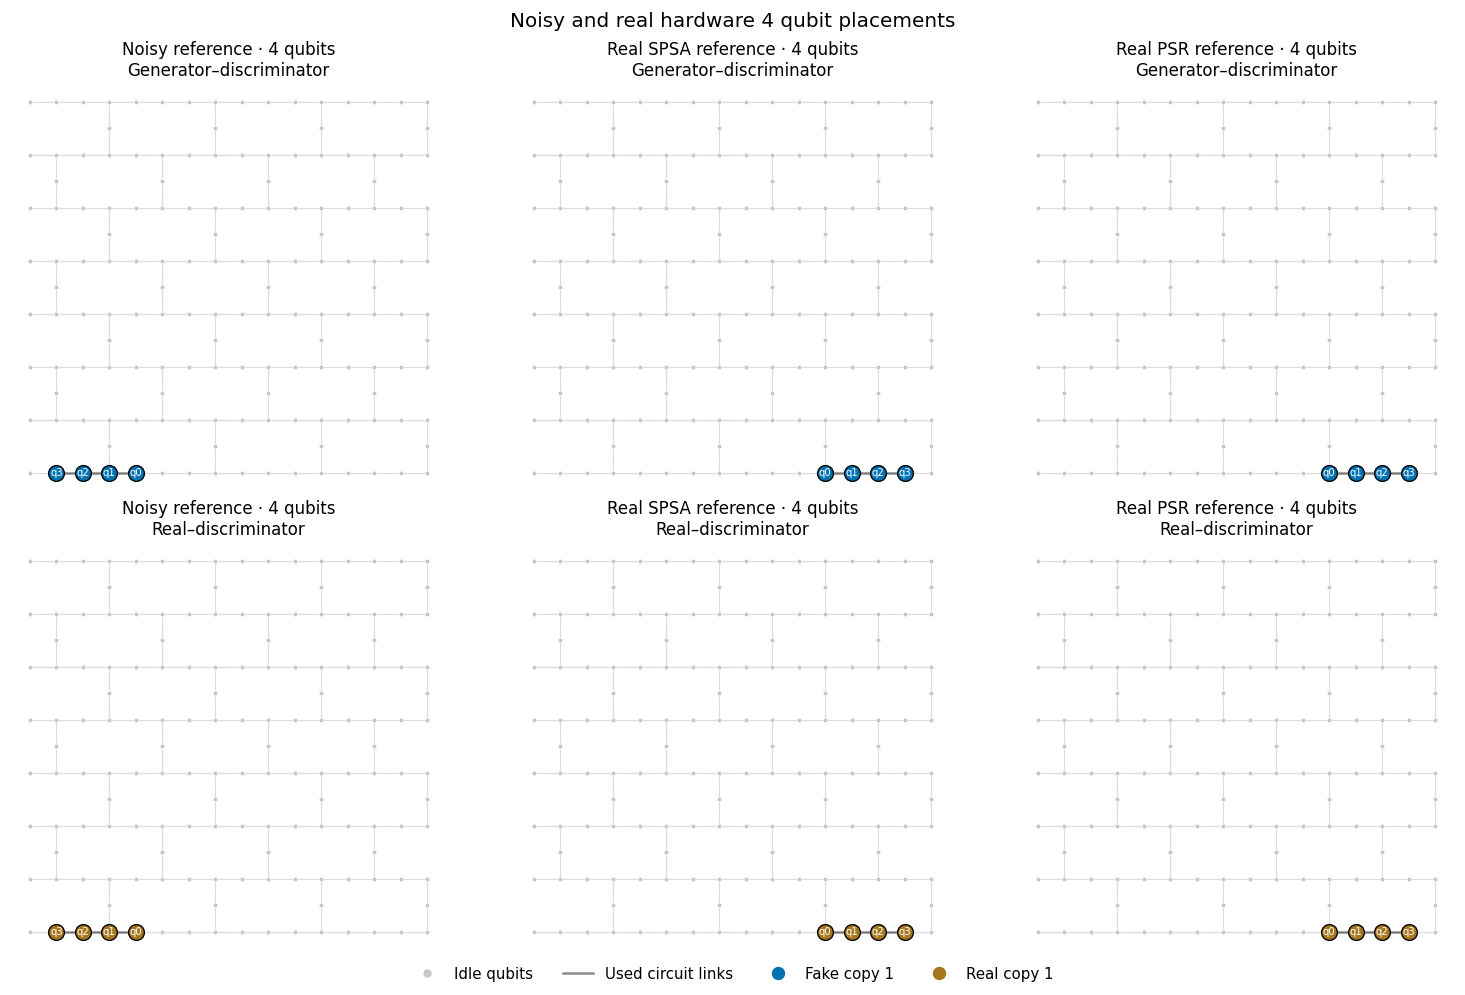

Reconstructing noisy, 8 qubits, qml-torch, base...
Reconstructing noisy, 16 qubits, qml-torch, base...


**4 placements joined in one figure; 0 skipped.** Labels show circuit qubits (q0, q1, …) at initial placement; black links are used by the transpiled circuit. These are offline reconstructions, with full initial/final mappings available in the returned circuit records.

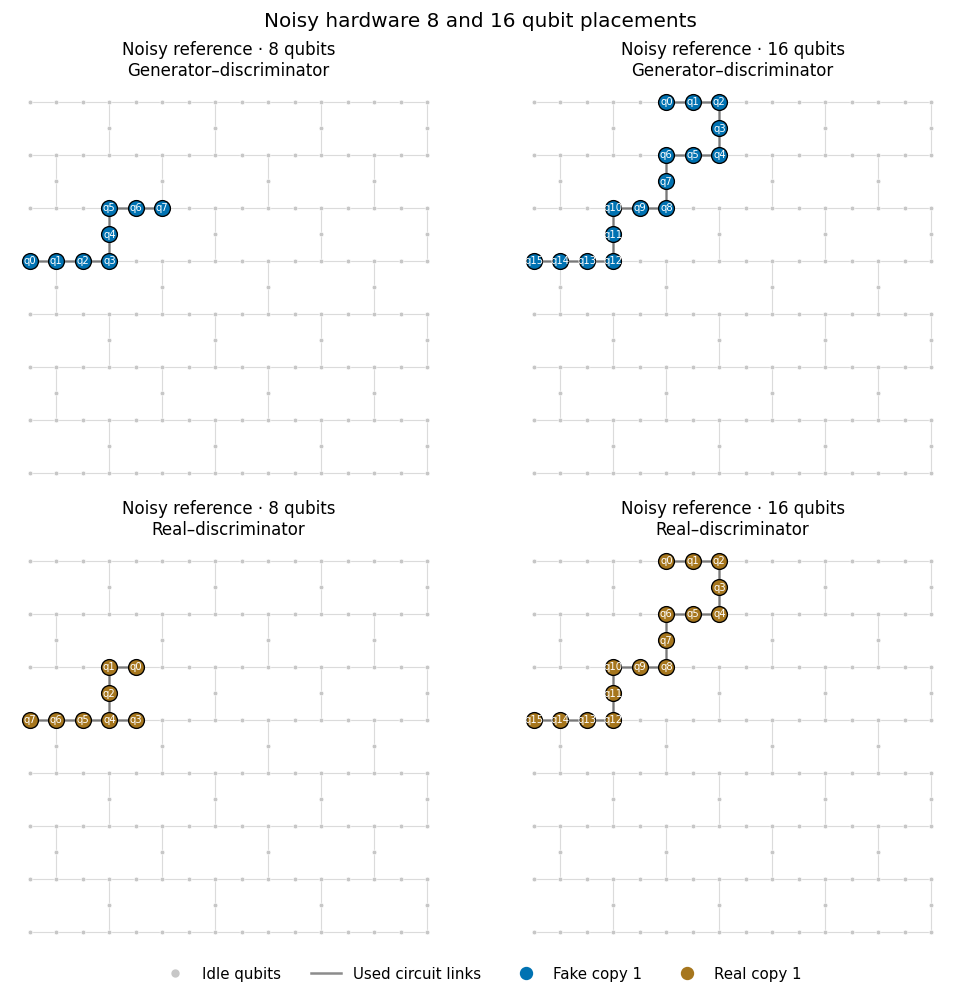

In [6]:
real_placements = analysis.show_transpilation_layouts(
    n_qubits=4,
    circuit=("generator-discriminator", "real-discriminator"),
    backend=("noisy", "real-spsa", "real-psr"),
    implementation=("qml-torch"),
    default_layout=USE_DEFAULT_LAYOUT,
    preset="base",
    save_figures=CREATE_PNG,
    filename="4_qubit_placements",
    title="Noisy and real hardware 4 qubit placements",
)

noisy_placements = analysis.show_transpilation_layouts(
    n_qubits=(8, 16),
    circuit=("generator-discriminator", "real-discriminator"),
    backend="noisy",
    implementation="qml-torch",
    default_layout=USE_DEFAULT_LAYOUT,
    preset="base",
    save_figures=CREATE_PNG,
    filename="noisy_qubit_placements",
    title="Noisy hardware 8 and 16 qubit placements",
)

### Optional FakeSherbrooke implementation comparison

Change the toggle, size, and implementation selectors to control this combined figure. It uses the same preset selector and PNG toggle.

In [ ]:
SHOW_FAKE_IMPLEMENTATION_COMPARISON = True

if SHOW_FAKE_IMPLEMENTATION_COMPARISON:
    fake_implementation_placements = analysis.show_transpilation_layouts(
        n_qubits=(4),
        circuit=("generator-discriminator", "real-discriminator"),
        backend="fake-real",
        implementation=("runtime-packed-sep"),
        default_layout=USE_DEFAULT_LAYOUT,
        preset=("base", "ang", "amp"),
        save_figures=CREATE_PNG,
        filename="runtime-packed-sep_placements",
        title="FakeSherbrooke runtime-packed separate placements",
    )

    fake_implementation_placements = analysis.show_transpilation_layouts(
        n_qubits=(4),
        circuit=("generator-discriminator", "real-discriminator"),
        backend="fake-real",
        implementation=("runtime-packed-join"),
        default_layout=USE_DEFAULT_LAYOUT,
        preset=("base", "ang"),
        save_figures=CREATE_PNG,
        filename="runtime-packed-join_placements",
        title="FakeSherbrooke runtime-packed joined placements",
    )

### Preset placement comparison

This six-panel example uses presets as columns and circuit choices as rows. Packed separate shows one group for base and **four groups for ang/amp**. At `n_qubits=4`, ang/amp therefore use 16 physical wires. Logical labels span q0–q15 across the four groups. Set `SHOW_PRESET_COMPARISON=False` to skip the figure, or change implementation to `qml-torch` to inspect its one-group templates. The zero-randomness source has the same generator ansatz across presets; real-data encodings differ.

You can request `implementation=("runtime-packed-sep", "runtime-packed-join")` with `preset=("base", "ang", "amp")`. With one backend, one size, and both circuit choices, the result joins **10 supported panels**, skipping the two joined-amplitude panels. Source/compilation errors and unavailable templates are also skipped; reasons are printed and retained in `preset_placements.skipped_combinations`. No substitute implementation is silently selected. If all combinations fail, the function reports that no placement is available and creates no figure.

Example selection (change the existing call’s arguments):

```python
implementation=("runtime-packed-sep", "runtime-packed-join"),
preset=("base", "ang", "amp"),
```


In [ ]:
SHOW_PRESET_COMPARISON = True

if SHOW_PRESET_COMPARISON:
    preset_placements = analysis.show_transpilation_layouts(
        n_qubits=8,
        circuit=("generator-discriminator", "real-discriminator"),
        backend="fake-real",
        implementation="runtime-packed-sep",
        default_layout=USE_DEFAULT_LAYOUT,
        preset=("base", "ang", "amp"),
        real_circuit_index=0,
        save_figures=CREATE_PNG,
        filename="runtime-packed-sep_example",
        title="8 qubit runtime-packed separate placement example",
    )

    preset_placements = analysis.show_transpilation_layouts(
        n_qubits=16,
        circuit=("generator-discriminator", "real-discriminator"),
        backend="fake-real",
        implementation=("runtime-packed-join"),
        default_layout=USE_DEFAULT_LAYOUT,
        preset=("base", "ang"),
        real_circuit_index=0,
        save_figures=CREATE_PNG,
        filename="runtime-packed-join_example",
        title="16 qubit runtime-packed joined placement example",
    )

### Offline reconstructed circuit comparison

The existing comparison table reports depth, two-qubit depth, CZ count, and active physical qubits. The noisy reference explicitly uses q4/rand0/seed0/SPSA; change `RUN_CONFIG_FILES` to compare another source. Differences between reconstructed compilations do not establish historical placement or an algorithm effect.

The comparison below uses `USE_DEFAULT_LAYOUT`; its placements are new compilations under that setting, not the historical training placements.

In [ ]:
TRANSPILE_COMPARISON_FILES = dict(BACKEND_FILES)

transpilation_comparison = {
    label: analysis.reconstruct_transpilation(
        analysis.load_backend(file),
        RUN_CONFIG_FILES[label],
        default_layout=USE_DEFAULT_LAYOUT,
        save_directory=(TRANSPILE_OUTPUT_DIR / label.lower().replace(' ', '_'))
            if SAVE_RECONSTRUCTED_CIRCUITS else None,
        show_summary=False,
    )
    for label, file in TRANSPILE_COMPARISON_FILES.items()
}
transpilation_comparison_rows = analysis.compare_transpilations(transpilation_comparison)